# Demonstration of MUSE

This is a demonstration of MUSE analysis on a multi-modality simulated data.

Feng Bao @ Altschuler & Wu Lab @ UCSF 2022.

Software provided as is under MIT License.

## Import packages

In [1]:
import multi_muse_sc as muse
import simulation_tool.multi_modal_simulation as simulation

import phenograph
from sklearn.decomposition import PCA
import numpy as np
from sklearn.metrics.cluster import adjusted_rand_score
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
np.random.seed(0)

## Generate simulation data


Simulation parameters

In [2]:
latent_dim = 100
num_cluster = 10
sample_size = 1000
latent_code_dim = 30
observed_data_dim = 500
sigma_1 = 0.1  
sigma_2 = 0.1
decay_coef_1 = 0.5 
decay_coef_2 = 0.1
merge_prob = 0.7



Use simulation tool to generate multi-modality data

In [3]:
data = simulation.multi_modal_simulator(
    num_cluster,
    sample_size,
    observed_data_dim,
    observed_data_dim,
    latent_code_dim,
    sigma_1,
    sigma_2,
    decay_coef_1,
    decay_coef_2,
    merge_prob,
)
data_a = data["data_a_dropout"]
data_b = data["data_b_dropout"]
label_a = data["data_a_label"]
label_b = data["data_b_label"]
label_true = data["true_cluster"]

## Analyses based on single modality

Learn features from single modality

In [4]:
data_a

array([[0.91915258, 0.20878533, 0.        , ..., 0.        , 1.15335547,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.76545324, 0.99363426, 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [5]:
data_ab = (data_a + 1) * (data_b + 1)
# data_ab = data_a * data_b

view_a_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(data_a)
view_b_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(data_b)
view_ab_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(data_ab)

In [6]:
print(f"data_a shape: {data_a.shape}")
print(f"data_b shape: {data_b.shape}")
print(f"view_a_feature shape: {view_a_feature.shape}")
print(f"view_b_feature shape: {view_b_feature.shape}")

data_a shape: (1000, 500)
data_b shape: (1000, 500)
view_a_feature shape: (1000, 100)
view_b_feature shape: (1000, 100)


Perform clustering using PhenoGraph

In [7]:
view_a_label, _, _ = phenograph.cluster(view_a_feature, random_state=42)
view_b_label, _, _ = phenograph.cluster(view_b_feature, random_state=42)
view_ab_label, _, _ = phenograph.cluster(view_ab_feature, random_state=42)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.07381653785705566 seconds
Jaccard graph constructed in 0.1596684455871582 seconds
Wrote graph to binary file in 0.005424022674560547 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.608665
After 3 runs, maximum modularity is Q = 0.612938
Louvain completed 23 runs in 0.46353602409362793 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 0.8255622386932373 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.06928324699401855 seconds
Jaccard graph constructed in 0.15028738975524902 seconds
Wrote graph to binary file in 0.005009174346923828 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.711669
Louvain completed 21 runs in 0.3397798538208008 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 0.6826395988464355

## Combined analysis using MUSE

MUSE learns the joint latent representation

In [8]:
X_embedded = TSNE(n_components=2, random_state=42).fit_transform(view_a_feature)
Y_embedded = TSNE(n_components=2, random_state=42).fit_transform(view_b_feature)
XY_embedded = TSNE(n_components=2, random_state=42).fit_transform(view_ab_feature)

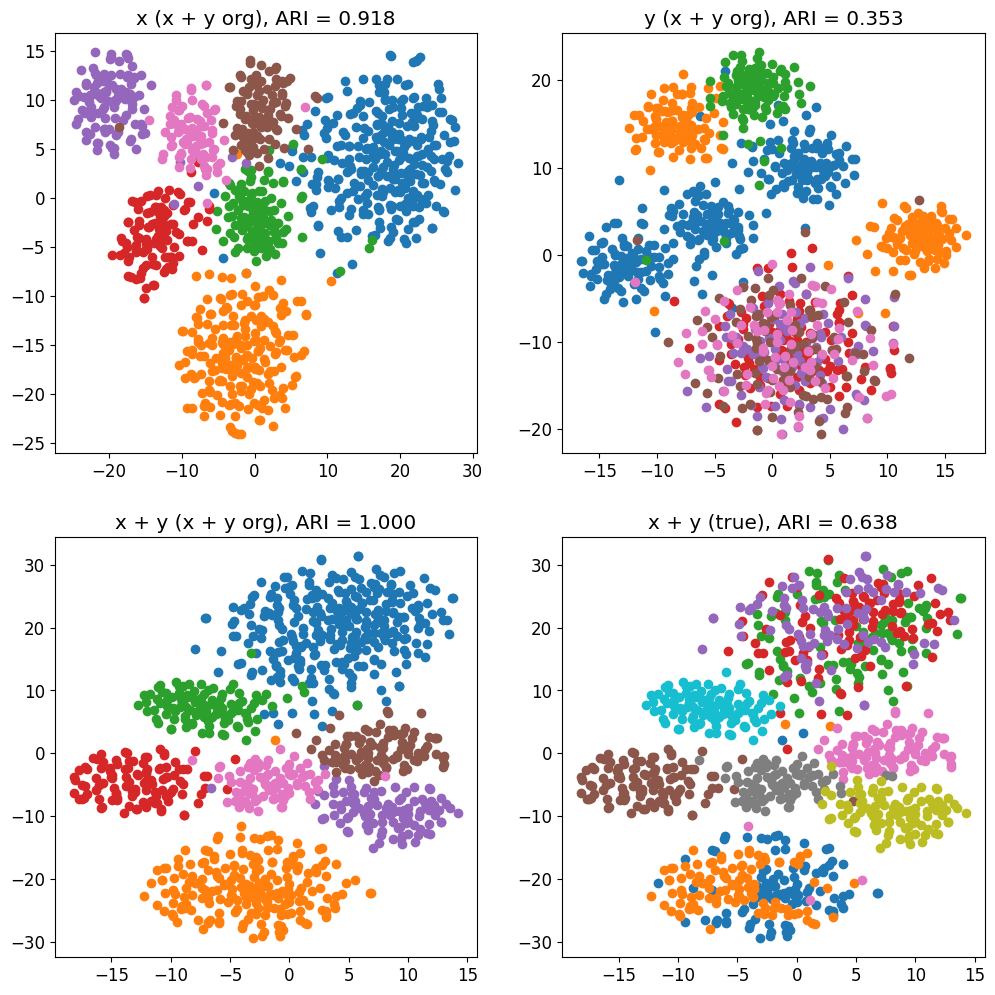

In [9]:
plt.rcParams['font.size'] = 12
plt.figure(figsize=(12, 12))
plt.subplot(2, 2, 1)
# 遍历每一个类别
for i in np.unique(view_ab_label):
    # 找到所有类别为i的索引
    idx = np.nonzero(view_ab_label == i)[0]
    # 将类别为i的点画成散点图
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    # 设置标题
    plt.title('x (x + y org), ARI = %01.3f' % adjusted_rand_score(view_ab_label, view_a_label))

plt.subplot(2, 2, 2)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(Y_embedded[idx, 0], Y_embedded[idx, 1])
    plt.title('y (x + y org), ARI = %01.3f' % adjusted_rand_score(view_ab_label, view_b_label))

plt.subplot(2, 2, 3)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(XY_embedded[idx, 0], XY_embedded[idx, 1])
    plt.title('x + y (x + y org), ARI = %01.3f' % adjusted_rand_score(view_ab_label, view_ab_label))

plt.subplot(2, 2, 4)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(XY_embedded[idx, 0], XY_embedded[idx, 1])
    plt.title('x + y (true), ARI = %01.3f' % adjusted_rand_score(view_ab_label, label_true))
plt.show()

In [26]:
outputs = muse.dual_muse_fit_predict(
    [data_a, data_b],
    [data_ab],
    [view_a_label, view_b_label],
    [view_ab_label],
    latent_dim=100,
    n_epochs=500,
    info_nce_lambda=10,
    weight_penalty=1,
    triplet_lambda=10,
)

++++++++++ DualMUSE for multi-modality single-cell analysis ++++++++++
#epoch: 0/200 	 total loss: 309.46 	 sc loss: 142.27 	 st loss: 99.90 	 infoNCE: 67.29 	 sc recon: 0.04 	 st recon: 0.07 	 sc sparse: 142.23 	 st sparse: 99.83 	 sc trip: 0.00 	 st trip: 0.00
#epoch: 50/200 	 total loss: 230.51 	 sc loss: 133.94 	 st loss: 94.00 	 infoNCE: 2.57 	 sc recon: 0.01 	 st recon: 0.02 	 sc sparse: 133.93 	 st sparse: 93.98 	 sc trip: 0.00 	 st trip: 0.00
#epoch: 100/200 	 total loss: 215.50 	 sc loss: 125.96 	 st loss: 88.39 	 infoNCE: 1.15 	 sc recon: 0.01 	 st recon: 0.02 	 sc sparse: 125.95 	 st sparse: 88.37 	 sc trip: 0.00 	 st trip: 0.00
#epoch: 150/200 	 total loss: 201.97 	 sc loss: 118.27 	 st loss: 82.99 	 infoNCE: 0.70 	 sc recon: 0.01 	 st recon: 0.02 	 sc sparse: 118.26 	 st sparse: 82.97 	 sc trip: 0.00 	 st trip: 0.00
#epoch: 0/200 	 total loss: 212.31 	 sc loss: 122.09 	 st loss: 87.84 	 infoNCE: 2.37 	 sc recon: 0.01 	 st recon: 0.02 	 sc sparse: 110.85 	 st sparse: 77.77 

## Perform clustering
PhenoGraph clustering

In [27]:
latent_sc, latent_st = outputs[0], outputs[1]
muse_label_sc, _, _ = phenograph.cluster(latent_sc, random_state=42)
muse_label_st, _, _ = phenograph.cluster(latent_st, random_state=42)
# 用kmeans聚类
from sklearn.cluster import KMeans
n_clusters = np.unique(view_ab_label).shape[0]
print(f"n_clusters: {n_clusters}")
kmeans_sc = KMeans(n_clusters=n_clusters).fit_predict(latent_sc)
kmeans_st = KMeans(n_clusters=n_clusters).fit_predict(latent_st)


Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.06748318672180176 seconds
Jaccard graph constructed in 0.4386711120605469 seconds
Wrote graph to binary file in 0.005232810974121094 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.898166
Louvain completed 21 runs in 0.9352447986602783 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 1.8987505435943604 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.0686640739440918 seconds
Jaccard graph constructed in 0.4911830425262451 seconds
Wrote graph to binary file in 0.004898548126220703 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.852955
Louvain completed 21 runs in 0.99456787109375 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 2.0178098678588867 seconds
n_clusters: 7


In [28]:
reconstruct_sc = (outputs[2])
reconstruct_st = (outputs[3])
encoded_sc = (outputs[4])
encoded_st = (outputs[5])
print(f"latent_sc: {latent_sc.shape}")
print(f"latent_st: {latent_st.shape}")
print(f"reconstruct_sc: {reconstruct_sc.shape}")
print(f"reconstruct_st: {reconstruct_st.shape}")
print(f"encoded_sc: {encoded_sc.shape}")
print(f"encoded_st: {encoded_st.shape}")

latent_sc: (1000, 100)
latent_st: (1000, 100)
reconstruct_sc: (2, 1000, 500)
reconstruct_st: (1, 1000, 500)
encoded_sc: (2, 1000, 128)
encoded_st: (1, 1000, 128)


## Visualization of latent spaces 
Latent spaces of single-modality features or MUSE features were visualized using tSNE, with ground truth cluster labels.

Cluster accuries were quantified using adjusted Rand index (ARI). ARI = 1 indicates perfectly discover true cell identities.

In [29]:
# import umap
# # 降维
# kmeans_st = KMeans(n_clusters=6, random_state=42).fit_predict(latent_sc)
# Y_tsne = TSNE(n_components=2, random_state=42).fit_transform(latent_sc)
# Y_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(latent_sc)

/home/lqr/miniconda3/envs/omics/lib/python3.9/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


[0 1 2 3 4 5 6]
[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6]


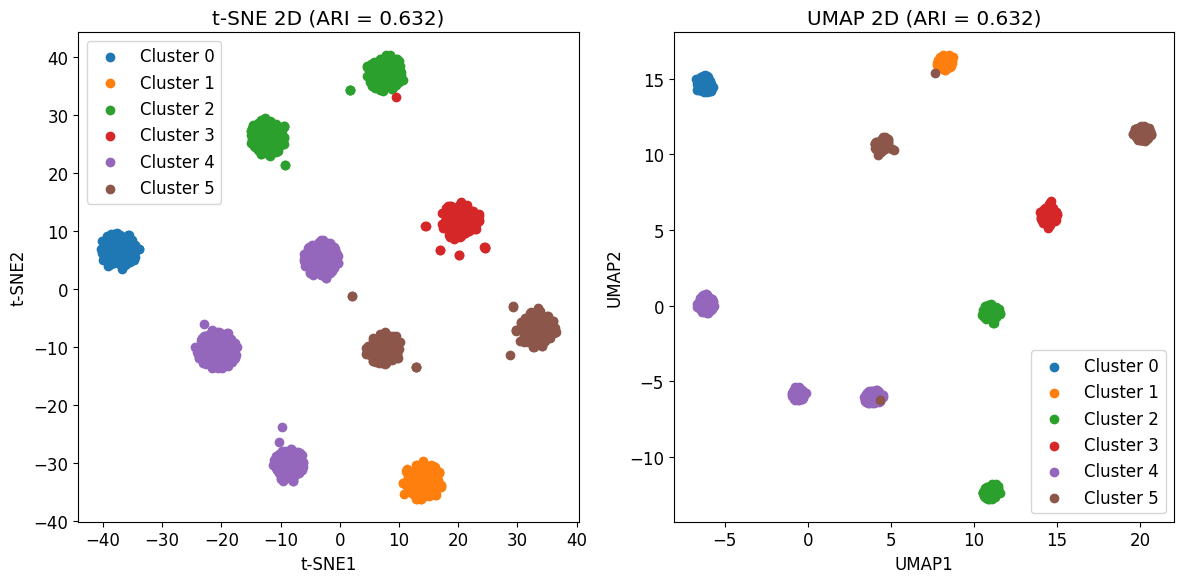

In [30]:
# TSNE UMAP 对比
# print(np.unique(view_ab_label))
# print(np.unique(muse_label_sc))
# print(np.unique(muse_label_st))


# # 创建图形
# fig = plt.figure(figsize=(12, 6))

# # TSNE 2D子图
# ax1 = fig.add_subplot(121)
# for i in np.unique(kmeans_st):
#     idx = np.nonzero(kmeans_st == i)[0]
#     ax1.scatter(Y_tsne[idx, 0], Y_tsne[idx, 1], label=f'Cluster {i}')
# ax1.set_title('t-SNE 2D (ARI = %.3f)' % adjusted_rand_score(view_ab_label, kmeans_st))
# ax1.set_xlabel('t-SNE1')
# ax1.set_ylabel('t-SNE2')
# ax1.legend()

# # UMAP 2D子图
# ax2 = fig.add_subplot(122)
# for i in np.unique(kmeans_st):
#     idx = np.nonzero(kmeans_st == i)[0]
#     ax2.scatter(Y_umap[idx, 0], Y_umap[idx, 1], label=f'Cluster {i}')
# ax2.set_title('UMAP 2D (ARI = %.3f)' % adjusted_rand_score(view_ab_label, kmeans_st))
# ax2.set_xlabel('UMAP1')
# ax2.set_ylabel('UMAP2')
# ax2.legend()

# # 调整布局
# plt.tight_layout()
# plt.show()

In [31]:
# # 3D可视化
# import plotly.express as px
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots

# # 降维
# Y_tsne = TSNE(n_components=3, random_state=42).fit_transform(latent_st)
# Y_umap = umap.UMAP(n_components=3, random_state=42).fit_transform(latent_st)
# kmeans_st_tsne = KMeans(n_clusters=6, random_state=42).fit_predict(Y_tsne)
# kmeans_st_umap = KMeans(n_clusters=6, random_state=42).fit_predict(Y_umap)

# # 创建子图
# fig = make_subplots(
#     rows=1, cols=2,
#     specs=[[{'type': 'scene'}, {'type': 'scene'}]],
#     subplot_titles=('t-SNE 3D', 'UMAP 3D')
# )

# # 添加t-SNE散点图
# for i in np.unique(kmeans_st_tsne):
#     idx = np.nonzero(kmeans_st_tsne == i)[0]
#     fig.add_trace(
#         go.Scatter3d(
#             x=Y_tsne[idx, 0],
#             y=Y_tsne[idx, 1],
#             z=Y_tsne[idx, 2],
#             mode='markers',
#             marker=dict(size=4),
#             name=f'Cluster {i}',
#         ),
#         row=1, col=1
#     )

# # 添加UMAP散点图
# for i in np.unique(kmeans_st_umap):
#     idx = np.nonzero(kmeans_st_umap == i)[0]
#     fig.add_trace(
#         go.Scatter3d(
#             x=Y_umap[idx, 0],
#             y=Y_umap[idx, 1],
#             z=Y_umap[idx, 2],
#             mode='markers',
#             marker=dict(size=4),
#             name=f'Cluster {i}',
#             showlegend=False  # 不重复显示图例
#         ),
#         row=1, col=2
#     )

# # 更新布局
# fig.update_layout(
#     title_text=f"3D Visualization (ARI = {adjusted_rand_score(view_ab_label, kmeans_st):.3f})",
#     width=1500,
#     height=600,
# )

# # 更新每个子图的坐标轴标签
# fig.update_scenes(
#     row=1, col=1,
#     xaxis_title="t-SNE1",
#     yaxis_title="t-SNE2",
#     zaxis_title="t-SNE3"
# )

# fig.update_scenes(
#     row=1, col=2,
#     xaxis_title="UMAP1",
#     yaxis_title="UMAP2",
#     zaxis_title="UMAP3"
# )

# # 显示图形
# fig.show()

# # 可选：保存为HTML文件
# # fig.write_html("3d_visualization.html")

In [32]:
X_embedded = TSNE(n_components=2, random_state=42).fit_transform(latent_sc)
Y_embedded = TSNE(n_components=2, random_state=42).fit_transform(latent_st)

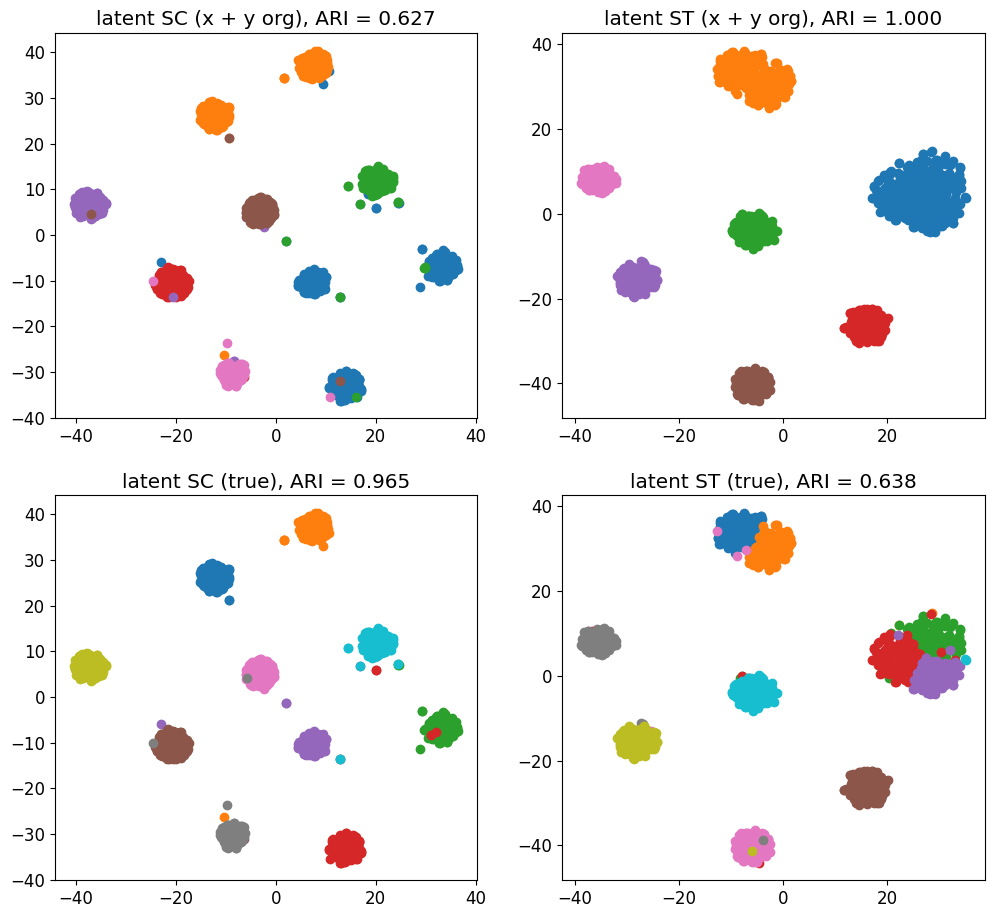

In [33]:
plt.figure(figsize=(12, 11))
plt.subplot(2, 2, 1)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('latent SC (x + y org), ARI = %01.3f' % adjusted_rand_score(view_ab_label, muse_label_sc))

plt.subplot(2, 2, 2)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(Y_embedded[idx, 0], Y_embedded[idx, 1])
    plt.title('latent ST (x + y org), ARI = %01.3f' % adjusted_rand_score(view_ab_label, muse_label_st))

plt.subplot(2, 2, 3)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('latent SC (true), ARI = %01.3f' % adjusted_rand_score(label_true, muse_label_sc))

plt.subplot(2, 2, 4)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(Y_embedded[idx, 0], Y_embedded[idx, 1])
    plt.title('latent ST (true), ARI = %01.3f' % adjusted_rand_score(label_true, muse_label_st))

In [34]:
print('phenograph SC and ST ARI: ', adjusted_rand_score(muse_label_sc, muse_label_st))
print('kmeans SC and ST ARI: ', adjusted_rand_score(kmeans_sc, kmeans_st))

phenograph SC and ST ARI:  0.626576555877544
kmeans SC and ST ARI:  0.8093910752751107


In [35]:
import os
os.makedirs('latent_sc_st', exist_ok=True)
np.save(f'latent_sc_st/latent_sc.npy', latent_sc)
np.save(f'latent_sc_st/latent_st.npy', latent_st)

**************************************************
S: torch.Size([1000, 100, 1])
G: torch.Size([1000, 100, 1])


 17%|█▋        | 83/500 [00:00<00:01, 411.06it/s]

100%|██████████| 500/500 [00:01<00:00, 400.70it/s]

Epoch 500: Loss -1.890415906906128
[[ 9.202754   -1.1127406  -1.2859361  ...  0.91870815 -0.9253347
  -0.01623669]
 [-2.338154    8.69098     0.95115995 ...  6.523628   -1.0747428
  -0.05987067]
 [ 1.1735344   0.76507413  9.372874   ...  1.1842868  -3.8744395
  -1.5639129 ]
 ...
 [ 0.37550285 -0.17941004 -0.9122215  ...  9.389876    0.21957119
  -0.6359944 ]
 [-3.9099565  -0.752665   -2.316539   ...  1.3067002   9.135455
   0.7183274 ]
 [-3.4113193  -1.368229   -0.92443836 ... -2.5698504   2.0989766
   8.447825  ]]


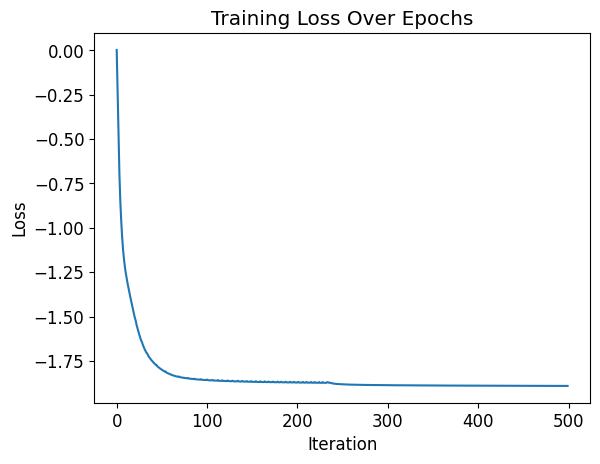

In [36]:
import sim_tangram.train_tangram as tg_cca
import torch

# tangram
tangram_sim, _ = tg_cca.read_csv_and_run_tangram(
    [torch.tensor(latent_sc, device='cuda:0')],
    [torch.tensor(latent_st, device='cuda:0')],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

**************************************************
S: torch.Size([1000, 100, 1])
G: torch.Size([1000, 100, 1])


 40%|███▉      | 199/500 [00:00<00:00, 1985.44it/s]

100%|██████████| 500/500 [00:00<00:00, 2000.94it/s]


Epoch 500: Loss -1.8371424674987793
[[10.485742   -0.8696819  -1.0738405  ...  1.1571513  -1.5873805
  -0.5012103 ]
 [-2.4139404  10.006519    1.2851607  ...  1.78623    -1.2734112
   0.02648181]
 [ 1.2207208   1.0243704   9.9860115  ...  1.4862479  -3.5674274
  -1.4316949 ]
 ...
 [ 0.6389436   0.4624605  -0.33170182 ... 10.211447   -0.7616161
  -1.5172073 ]
 [-4.141692   -1.3956934  -2.1954508  ...  0.14949834  9.404808
  -1.0966715 ]
 [-3.3292723  -1.2113044  -0.72985584 ... -2.5195057   5.0302277
   9.338665  ]]


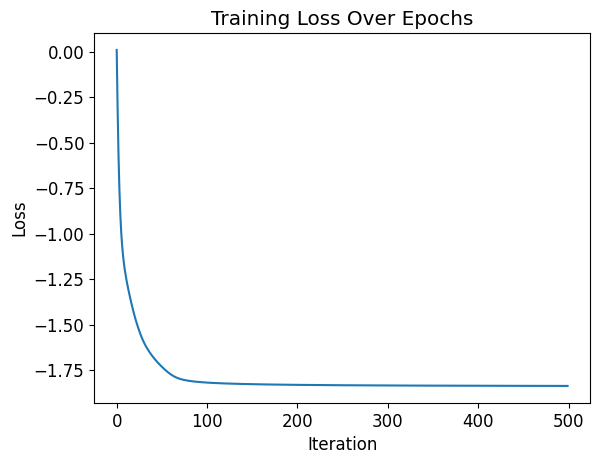

In [37]:
# 用cosine_similarity驱动的tangram进行计算
import cos_tg.train_tangram as tg_cos

# tangram
cos_sim_tg, _ = tg_cos.read_csv_and_run_tangram(
    [torch.tensor(latent_sc, device='cuda:0')],
    [torch.tensor(latent_st, device='cuda:0')],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

In [38]:
# 计算cosine_similarity
from sklearn.metrics.pairwise import cosine_similarity
cos = cosine_similarity(latent_sc, latent_st)
cos_mapping = cos.argmax(axis=1)
for i in range(len(cos_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {cos_mapping[i]:4d}", end="\t")
print()
print('*'*50)

# 检验cosine_similarity驱动的tangram
cos_tg_mapping = cos_sim_tg.argmax(axis=1)
for i in range(len(cos_tg_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {cos_tg_mapping[i]:4d}", end="\t")
print()
print('*'*50)

# 检验CCA驱动的tangram
tangram_mapping = tangram_sim.argmax(axis=1)
for i in range(len(tangram_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {tangram_mapping[i]:4d}", end="\t")
print()
print('*'*50)



 0:    0	 1:    1	 2:    2	 3:    3	 4:    4	
 5:    5	 6:    6	 7:    7	 8:    8	 9:    9	
10:   10	11:   11	12:   12	13:   13	14:   14	
15:   15	16:   16	17:   17	18:   18	19:   19	
20:   20	21:   21	22:   22	23:   23	24:   24	
25:   25	26:   26	27:   27	28:   28	29:   29	
**************************************************

 0:    0	 1:    1	 2:    2	 3:    3	 4:    4	
 5:    5	 6:    6	 7:    7	 8:    8	 9:    9	
10:   10	11:   11	12:   12	13:   13	14:   14	
15:   15	16:   16	17:   17	18:   18	19:   19	
20:   20	21:   21	22:   22	23:   23	24:   24	
25:   25	26:   26	27:   27	28:   28	29:   29	
**************************************************

 0:    0	 1:    1	 2:    2	 3:    3	 4:    4	
 5:    5	 6:    6	 7:    7	 8:    8	 9:    9	
10:   10	11:   11	12:   12	13:   13	14:   14	
15:   15	16:   16	17:   17	18:   18	19:   19	
20:   20	21:   21	22:   22	23:   23	24:   24	
25:   25	26:   26	27:   27	28:   28	29:   29	
**************************************************


In [39]:
# 输出cos对角线的元素
for i in range(len(cos_mapping)):
    if i < 30:
        print(cos[i, i], end="\t")

0.7646563	0.85573167	0.8545704	0.80681074	0.7989965	0.82669693	0.81132615	0.7625928	0.7982886	0.81305534	0.8750376	0.7933534	0.780715	0.8294902	0.87518936	0.8573201	0.8052611	0.7435053	0.764333	0.76704204	0.7889935	0.8169598	0.782148	0.7352425	0.77784425	0.75899786	0.80360436	0.7542852	0.76651764	0.79692465	

In [40]:
cos

array([[ 0.7646563 , -0.24200201, -0.20989512, ...,  0.32691124,
        -0.13847171,  0.10273167],
       [-0.33743072,  0.85573167,  0.45524317, ..., -0.02809558,
        -0.08517756, -0.30615214],
       [-0.29720038,  0.43361607,  0.8545704 , ...,  0.02174537,
        -0.07566605, -0.26449835],
       ...,
       [ 0.35838938, -0.07828817, -0.02626653, ...,  0.7596924 ,
        -0.0196272 ,  0.02738076],
       [-0.12633775, -0.17030923, -0.19692048, ..., -0.00339555,
         0.8046413 , -0.05193974],
       [ 0.08690179, -0.35367417, -0.33048663, ..., -0.07593388,
         0.02165559,  0.8286129 ]], dtype=float32)

In [41]:
# 计算acc
gt = np.array(range(sample_size))
cos_acc = np.sum(cos_mapping == gt) / sample_size
tangram_acc = np.sum(tangram_mapping == gt) / sample_size
cos_tg_acc = np.sum(cos_tg_mapping == gt) / sample_size
print("cos accuracy:", cos_acc)
print("tangram accuracy:", tangram_acc)
print("cos_tg accuracy:", cos_tg_acc)


cos accuracy: 1.0
tangram accuracy: 0.984
cos_tg accuracy: 1.0
